In [1]:
import random

import torch
from torch import nn
from torch.utils import data
from torch.nn import functional as F
import torchvision
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
USE_ACCELERATOR = True
TORCH_SEED = 2147483647
SEED = 42

# data
DATA_PATH = "./data"
NUM_WORKERS_DATALOADER = 4
TRAIN_SPLIT = 0.8
VAL_SPLIT = 0.1
TEST_SPLIT = 0.1
assert TRAIN_SPLIT + VAL_SPLIT + TEST_SPLIT == 1.0

# hparams
BATCH_SIZE = 512
EPOCHS = 1
LR = 3e-4
WEIGHT_DECAY = 0.05
START_M = 0.996
END_M = 1.0

random.seed(SEED)
torch.manual_seed(TORCH_SEED)
torch.cuda.manual_seed_all(TORCH_SEED)
torch.set_float32_matmul_precision("high")  # use tf32

In [3]:
class SelfAttention(nn.Module):
    def __init__(self, dim: int, num_heads: int, attn_drop: float = 0.0, proj_drop: float = 0.0) -> None:
        super().__init__()
        if dim % num_heads != 0:
            msg = f"dim {dim} not divisible by num_heads {num_heads}"
            raise ValueError(msg)

        self.dim = dim
        self.num_heads = num_heads
        self.head_dim = self.dim // self.num_heads
        self.scale = self.head_dim**-0.5

        self.qkv = nn.Linear(dim, 3 * dim, bias=True)
        self.attn_drop_p = attn_drop
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x: (B, T, D). out: (B, T, D)"""
        B, T, D = x.size()
        x_qkv = self.qkv(x)  # (B, T, D) @ (D, 3 * D) = (B, T, 3 * D)
        x_q, x_k, x_v = x_qkv.split(self.dim, dim=-1)  # (B, T, D) each
        x_q = x_q.view(B, T, self.num_heads, D // self.num_heads).transpose(-2, -3)  # (B, H, T, Hd)
        x_k = x_k.view(B, T, self.num_heads, D // self.num_heads).transpose(-2, -3)  # (B, H, T, Hd)
        x_v = x_v.view(B, T, self.num_heads, D // self.num_heads).transpose(-2, -3)  # (B, H, T, Hd)
        y = F.scaled_dot_product_attention(
            x_q,
            x_k,
            x_v,
            scale=self.scale,
            dropout_p=self.attn_drop_p if self.training else 0.0,
        )  # (B, H, T, Hd)
        y = y.transpose(-2, -3).contiguous().view(B, T, D)
        y = self.proj(y)
        return self.proj_drop(y)


class MLP(nn.Module):
    def __init__(self, dim: int, hidden_dim: int, drop: float = 0.0) -> None:
        super().__init__()
        self.fc1 = nn.Linear(dim, hidden_dim, bias=True)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_dim, dim, bias=True)
        self.drop = nn.Dropout(drop)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        return self.drop(x)


class TransformerBlock(nn.Module):
    """Standard pre-norm transformer block with self-attention and MLP."""

    def __init__(
        self, dim: int, num_heads: int, mlp_ratio: float = 4.0, attn_drop: float = 0.0, proj_drop: float = 0.0
    ) -> None:
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = SelfAttention(dim=dim, num_heads=num_heads, attn_drop=attn_drop, proj_drop=proj_drop)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim=dim, hidden_dim=int(dim * mlp_ratio), drop=proj_drop)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x: (B, T, D). out: (B, T, D)"""
        x = x + self.attn(self.norm1(x))
        return x + self.mlp(self.norm2(x))


with torch.inference_mode():
    layer = TransformerBlock(dim=768, num_heads=4)
    assert layer(torch.rand((10, 196, 768))).shape == (10, 196, 768)

In [4]:
class PatchEmbed(nn.Module):
    """
        Converts an image to a sequence of patch embeddings.
    A standard Vision Transformer creates patch tokens with a strided convolution. Each patch becomes a vector in R_D.

        Input:  (B, C, H, W)
        Output: (B, N, D) where N = (H / P) * (W / P)
    """

    def __init__(
        self,
        img_size: int = 224,
        patch_size: int = 16,
        in_chans: int = 3,
        embed_dim: int = 768,
    ) -> None:
        super().__init__()
        if img_size % patch_size != 0:
            msg = f"img_size ({img_size}) must be divisible by patch_size ({patch_size})"
            raise ValueError(msg)

        self.img_size = img_size
        self.patch_size = patch_size
        self.grid_size = img_size // patch_size
        self.num_patches = self.grid_size**2

        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size, bias=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.proj(x)  # (B, D, G, G)
        return x.flatten(-2).transpose(-1, -2)  # (B, G*G, D)


with torch.inference_mode():
    layer = PatchEmbed()
    assert layer(torch.rand((10, 3, 224, 224))).shape == (10, 196, 768)

In [5]:
# (1,3,224,224) image
# divide into 16x16 patches
# -> 14x14 patches, each (3, 16, 16), totalling (1, 14*14, 3, 16, 16)
# flatten patches
# -> 14x14 patches, each (3*16*16), totalling (1, 196, 768) # pixel space
# linear projection to d_model which is also 768 for vit-b @ (768, 768)
# -> 14x14 patches, each (768), totalling (1, 196, 768) # embedding space
# optional cls token (we skip)
# add learnable positional embeddings to patch embeddings
# -> still (1, 196, 768)
class ViTEncoder(nn.Module):
    """
    Minimal ViT-style patch encoder.

    This version does not use a CLS token. The I-JEPA method section describes
    patch-level representations and does not require CLS during pretraining.
    """

    def __init__(
        self,
        img_size: int = 224,
        patch_size: int = 16,
        in_chans: int = 3,
        embed_dim: int = 768,
        depth: int = 12,
        num_heads: int = 12,
        mlp_ratio: float = 4.0,
        attn_drop: float = 0.0,
        proj_drop: float = 0.0,
    ) -> None:
        super().__init__()
        self.patch_embed = PatchEmbed(img_size=img_size, patch_size=patch_size, in_chans=in_chans, embed_dim=embed_dim)
        self.num_patches = self.patch_embed.num_patches

        self.pos_embed = nn.Parameter(
            torch.zeros(1, self.num_patches, embed_dim)
        )  # 196 possible positions, each with 768-length embedding
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        self.blocks = nn.ModuleList(
            TransformerBlock(
                dim=embed_dim, num_heads=num_heads, mlp_ratio=mlp_ratio, attn_drop=attn_drop, proj_drop=proj_drop
            )
            for _ in range(depth)
        )
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, images: torch.Tensor, patch_indices: torch.Tensor | None = None) -> torch.Tensor:
        """
        images: (B, C, H, W)
        patch_indices: None or a 1D tensor of indices into the patch sequence

        Returns: (B, T, D)
        """
        x = self.patch_embed(images)  # (B, N, D)
        if patch_indices is None:
            x = x + self.pos_embed  # broadcast, (B, N, D)
        else:
            if patch_indices.ndim != 1:
                raise ValueError("patch_indices must be a 1D tensor in this minimal implementation")
            x = x[:, patch_indices, :] + self.pos_embed[:, patch_indices, :]
        for block in self.blocks:
            x = block(x)
        return self.norm(x)


with torch.inference_mode():
    layer = ViTEncoder()
    assert layer(torch.rand((10, 3, 224, 224)), None).shape == (10, 196, 768)
    assert layer(torch.rand((10, 3, 224, 224)), torch.tensor([0, 1, 2])).shape == (10, 3, 768)

In [6]:
def sample_block_on_grid(
    grid_size: int,
    scale_range: tuple[float, float],
    aspect_ratio_range: tuple[float, float],
) -> tuple[int, int, int, int]:
    """
    Samples a rectangle on a grid_size x grid_size patch grid.

    Returns: (top, left, height, width) in patch coordinates.
    """
    G = grid_size
    N = G**2

    scale = random.uniform(*scale_range)
    aspect_ratio = random.uniform(*aspect_ratio_range)

    area = scale * N
    w = int(round((area * aspect_ratio) ** 0.5))  # sqrt(w*h * (w/h))
    h = int(round((area / aspect_ratio) ** 0.5))

    w = max(1, min(w, G))  # at least 1 patch wide, at most G patches wide
    h = max(1, min(h, G))  # at least 1 patch tall, at most G patches tall

    top = random.randint(0, G - h)
    left = random.randint(0, G - w)

    return top, left, h, w


def rect_to_indices(grid_size: int, top: int, left: int, h: int, w: int) -> torch.Tensor:
    """
    Converts a rectangle to flat patch indices in row major order.
    """
    rows = torch.arange(top, top + h)
    cols = torch.arange(left, left + w)
    rr, cc = torch.meshgrid(rows, cols, indexing="ij")
    return (rr * grid_size + cc).flatten()

In [7]:
import dataclasses


@dataclasses.dataclass
class IJEPAMasks:
    context_indices: torch.Tensor
    target_blocks_indices: list[torch.Tensor]


class IJEPAMaskGenerator(nn.Module):
    def __init__(
        self,
        grid_size: int,
        num_targets: int = 4,
        target_scale: tuple[float, float] = (0.15, 0.2),
        target_aspect: tuple[float, float] = (0.75, 1.5),
        context_scale: tuple[float, float] = (0.85, 1.0),
        context_aspect: tuple[float, float] = (1.0, 1.0),
    ):
        super().__init__()
        self.grid_size = grid_size
        self.num_targets = num_targets
        self.target_scale = target_scale
        self.target_aspect = target_aspect
        self.context_scale = context_scale
        self.context_aspect = context_aspect

    def __call__(self) -> IJEPAMasks:
        G = self.grid_size

        target_blocks_indices: list[torch.Tensor] = []
        target_union = torch.zeros(G * G, dtype=torch.bool)

        for _ in range(self.num_targets):
            top, left, h, w = sample_block_on_grid(G, self.target_scale, self.target_aspect)
            idx = rect_to_indices(G, top, left, h, w)
            target_blocks_indices.append(idx)
            target_union[idx] = True

        c_top, c_left, c_h, c_w = sample_block_on_grid(G, self.context_scale, self.context_aspect)
        context_indices = rect_to_indices(G, c_top, c_left, c_h, c_w)

        # NOTE: this removes ALL overlap between context and targets for a single image by using the union of targets, which leaves us with less context when we are considering a context that has no overlap with the targets if there is some other mask that overlaps significantly with the context.
        keep = ~target_union[context_indices]
        context_indices = context_indices[keep]
        return IJEPAMasks(context_indices=context_indices, target_blocks_indices=target_blocks_indices)

In [8]:
class IJEPAPredictor(nn.Module):
    def __init__(
        self,
        embed_dim: int,
        depth: int = 6,
        num_heads: int = 12,
        mlp_ratio: float = 4.0,
        attn_drop: float = 0.0,
        proj_drop: float = 0.0,
    ) -> None:
        super().__init__()
        # a shared learnable base for every output embedding to start from
        # a form of strong regularization/weight sharing
        self.mask_tokens = nn.Parameter(torch.zeros(1, 1, embed_dim))
        nn.init.trunc_normal_(self.mask_tokens, std=0.02)
        self.blocks = nn.ModuleList(
            TransformerBlock(
                dim=embed_dim,
                num_heads=num_heads,
                mlp_ratio=mlp_ratio,
                attn_drop=attn_drop,
                proj_drop=proj_drop,
            )
            for _ in range(depth)
        )
        self.norm = nn.LayerNorm(embed_dim)

    def forward(
        self,
        context_tokens: torch.Tensor,
        target_pos_embeddings: torch.Tensor,
    ) -> torch.Tensor:
        """
        The input sequence is the context tokens followed by mask tokens, one per target patch position, each augmented with the positional embedding for that patch position. The output sequence is the same length, and we read out the final tokens corresponding to the target positions

        context_tokens: (B, Nc, D)
        target_pos_embeddings: (B, Nt, D)

        Returns: (B, Nt, D) the predicted target patch embeddings
        """
        B, Nc, D = context_tokens.shape
        _, Nt, _ = target_pos_embeddings.shape

        mask_tokens = self.mask_tokens.expand(B, Nt, D) + target_pos_embeddings
        x = torch.cat([context_tokens, mask_tokens], dim=1)  # (B, Nc + Nt, D)
        for block in self.blocks:
            x = block(x)
        x = self.norm(x)
        return x[:, Nc:, :]

In [9]:
class IJEPA(nn.Module):
    def __init__(
        self,
        img_size: int = 224,
        patch_size: int = 16,
        in_chans: int = 3,
        embed_dim: int = 768,
        enc_depth: int = 12,
        enc_heads: int = 12,
        pred_depth: int = 6,
        pred_heads: int = 12,
        mlp_ratio: float = 4.0,
    ) -> None:
        super().__init__()
        self.context_encoder = ViTEncoder(
            img_size=img_size,
            patch_size=patch_size,
            in_chans=in_chans,
            embed_dim=embed_dim,
            depth=enc_depth,
            num_heads=enc_heads,
            mlp_ratio=mlp_ratio,
        )
        self.target_encoder = ViTEncoder(
            img_size=img_size,
            patch_size=patch_size,
            in_chans=in_chans,
            embed_dim=embed_dim,
            depth=enc_depth,
            num_heads=enc_heads,
            mlp_ratio=mlp_ratio,
        )

        self._init_teacher_from_student()

        self.predictor = IJEPAPredictor(
            embed_dim=embed_dim, depth=pred_depth, num_heads=pred_heads, mlp_ratio=mlp_ratio
        )

        G = self.context_encoder.patch_embed.grid_size
        self.mask_generator = IJEPAMaskGenerator(grid_size=G)

    @torch.no_grad()
    def _init_teacher_from_student(self) -> None:
        for p_s, p_t in zip(self.context_encoder.parameters(), self.target_encoder.parameters(), strict=True):
            p_t.data.copy_(p_s.data)
        # freeze teacher
        for p_t in self.target_encoder.parameters():
            p_t.requires_grad_(False)

    @torch.no_grad()
    def ema_update_teacher(self, momentum: float) -> None:
        """
        Teacher update: theta_bar <- m * theta_bar + (1 - m) * theta
        """
        for p_s, p_t in zip(self.context_encoder.parameters(), self.target_encoder.parameters(), strict=True):
            p_t.data.mul_(momentum).add_(p_s.data, alpha=(1.0 - momentum))

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        """
        Computes the I-JEPA loss on a batch.

        This version loops over samples for clarity, since masks differ per image.
        """
        B = images.shape[0]
        device = images.device

        with torch.no_grad():
            all_target_tokens = self.target_encoder(images)  # (B, Nt, D)

        pos_embed = self.context_encoder.pos_embed  # (1, N, D)

        total_loss = torch.tensor(0.0, device=device)
        total_blocks = 0
        for b in range(B):
            masks = self.mask_generator()
            context_indices = masks.context_indices.to(device)

            context_tokens = self.context_encoder(images[b : b + 1], patch_indices=context_indices)  # (1, Nc, D)
            for target_block_indices in masks.target_blocks_indices:
                target_block_indices = target_block_indices.to(device)
                target_block = all_target_tokens[b : b + 1, target_block_indices, :]  # (1, Nt, D)
                target_pos_embed = pos_embed[:, target_block_indices, :]  # (1, Nt, D)

                pred = self.predictor(context_tokens, target_pos_embed)  # (1, Nt, D)
                loss = F.mse_loss(pred, target_block, reduction="mean")
                total_loss += loss
                total_blocks += 1

        return total_loss / max(1, total_blocks)

In [10]:
import math


def cosine_schedule(start: float, end: float, step: int, total_steps: int) -> float:
    if total_steps <= 1:
        return end
    t = step / (total_steps - 1)
    return end - (end - start) * (0.5 * (1 + math.cos(math.pi * t)))


def momentum_schedule(step: int, total_steps: int, start_m: float = START_M, end_m: float = END_M) -> float:
    return cosine_schedule(start_m, end_m, step, total_steps)


def train_ijepa(
    model: IJEPA,
    dataloader: data.DataLoader,
    optimizer: torch.optim.Optimizer,
    curr_epoch: int,
    max_epochs: int,
) -> None:
    model.train()
    total_steps = len(dataloader) * max_epochs
    for batch, (images, _) in enumerate(dataloader):
        images = images.to(device)

        # forward, only wrap this part in autocast since we want full precision for the optimizer step and teacher update for stability
        with torch.autocast(device_type=device.type, dtype=torch.bfloat16):
            loss = model(images)

        # backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        global_step = curr_epoch * len(dataloader) + batch
        m = momentum_schedule(global_step, total_steps)
        model.ema_update_teacher(momentum=m)

        if global_step % 50 == 0:
            print(f"epoch={curr_epoch}, step={global_step}, loss={loss.item():.6f} momentum={m:.6f}")


def test_ijepa(
    model: IJEPA,
    dataloader: data.DataLoader,
) -> None:
    size = len(dataloader.dataset)  # ty:ignore[invalid-argument-type]
    num_batches = len(dataloader)
    model.eval()
    test_loss = 0.0
    with torch.inference_mode():
        for batch, (images, _) in enumerate(dataloader):
            images = images.to(device)
            with torch.autocast(device_type=device.type, dtype=torch.bfloat16):
                loss = model(images)
            test_loss += loss.item()
    test_loss /= num_batches
    print(f"avg loss={test_loss:>8f} \n")

In [11]:
transform = transforms.Compose([transforms.ToTensor()])
trainset = torchvision.datasets.CIFAR10(root=DATA_PATH, train=True, download=True, transform=transform)

# stack all train images together into a tensor of shape
# (50000, 3, 32, 32)
x = torch.stack([sample[0] for sample in data.ConcatDataset([trainset])])
print(x.shape)

# get the mean of each channel
mean = torch.mean(x, dim=(0, 2, 3))
std = torch.std(x, dim=(0, 2, 3))
mean, std

/home/felixngfender/workplaces/pea/.venv/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


torch.Size([50000, 3, 32, 32])


(tensor([0.4914, 0.4822, 0.4465]), tensor([0.2470, 0.2435, 0.2616]))

In [12]:
transform = transforms.Compose(
    # pillow to tensor, per-channel normalization so that it is gaussian (mean=0, std=1)
    [transforms.ToTensor(), transforms.Normalize(mean.tolist(), std.tolist())]
)
# 32x32 RGB images representing 10 classes
trainset = torchvision.datasets.CIFAR10(root=DATA_PATH, train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root=DATA_PATH, train=False, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS_DATALOADER
)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS_DATALOADER
)

classes = ("plane", "car", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck")

 frog plane plane horse   cat  deer  bird horse truck horse   car   cat   car plane truck   car   cat plane   cat plane   car   car  bird  bird truck truck   dog plane  deer  ship truck  frog plane plane  bird   cat  ship  bird plane   dog  ship  ship plane   car  frog   car horse  frog   car  deer   cat   car  ship   cat truck plane  bird  deer  bird   car   car   dog truck  frog  deer  deer truck horse  bird   car  bird  frog   dog  frog  deer  frog   cat truck  bird  deer truck   car plane plane  bird  bird horse  ship  deer  deer  frog horse horse  ship   cat truck  deer  frog   cat   cat  frog   car   cat   car   cat  ship  ship plane horse   cat  ship   dog   dog  frog truck plane plane   car truck plane  bird plane   cat   cat   car  deer horse truck   cat plane   car truck   dog horse   cat horse   car  ship   cat  bird   cat horse plane  bird horse   dog  bird  deer  ship truck plane  deer horse truck horse   dog  bird   dog   dog   cat horse truck  bird  frog  ship   car   ca

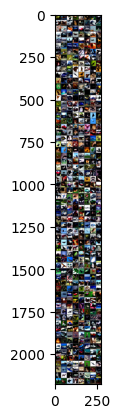

In [13]:
def imshow(img: torch.Tensor) -> None:
    img = img.permute(1, 2, 0).cpu()
    img = img * mean + std
    img = img.clamp(0, 1)
    plt.imshow(img)


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(" ".join("%5s" % classes[labels[j]] for j in range(BATCH_SIZE)))

In [14]:
device = (
    torch.accelerator.current_accelerator()
    if torch.accelerator.is_available() and USE_ACCELERATOR
    else torch.device("cpu")
)
print("using device", device)

model = IJEPA(
    img_size=32,
    patch_size=2,
    in_chans=3,
    embed_dim=128,
    enc_depth=4,
    enc_heads=4,
    pred_depth=2,
    pred_heads=4,
).to(device)
# model.compile()
optimizer = torch.optim.AdamW(
    list(model.context_encoder.parameters()) + list(model.predictor.parameters()), lr=LR, weight_decay=WEIGHT_DECAY
)

for epoch in range(EPOCHS):
    train_ijepa(model, trainloader, optimizer, curr_epoch=epoch, max_epochs=EPOCHS)
    test_ijepa(model, testloader)

torch.save(model.state_dict(), "ijepa_cifar10.pth")

using device cuda
epoch=0, step=0, loss=2.044829 momentum=0.996000
epoch=0, step=50, loss=0.580337 momentum=0.998097
avg loss=0.522986 

